In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima

In [2]:
df = pd.read_csv("sample_fish_population_dataset.csv")

In [3]:
df["date"] = pd.to_datetime(df["date"])

In [4]:
df_grouped = df.groupby(['date', 'species'])['count'].sum().reset_index()

In [5]:
species_list = df_grouped['species'].unique()

In [6]:
def forecast_species(data, species_name, steps=12):
    # Filter species
    sp_data = data[data['species'] == species_name].set_index('date')
    ts = sp_data['count']

    # Train ARIMA automatically
    model = auto_arima(ts, seasonal=True, stepwise=True, suppress_warnings=True)
    
    # Forecast
    forecast = model.predict(n_periods=steps)
    future_dates = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(), periods=steps, freq='MS')
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(ts.index, ts, label="Actual (History)")
    plt.plot(future_dates, forecast, label="Forecast", linestyle="--")
    plt.title(f"Forecast for {species_name}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.show()
    
    return forecast


🔹 Forecasting for Sardine ...


c:\Users\a30ku\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\a30ku\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


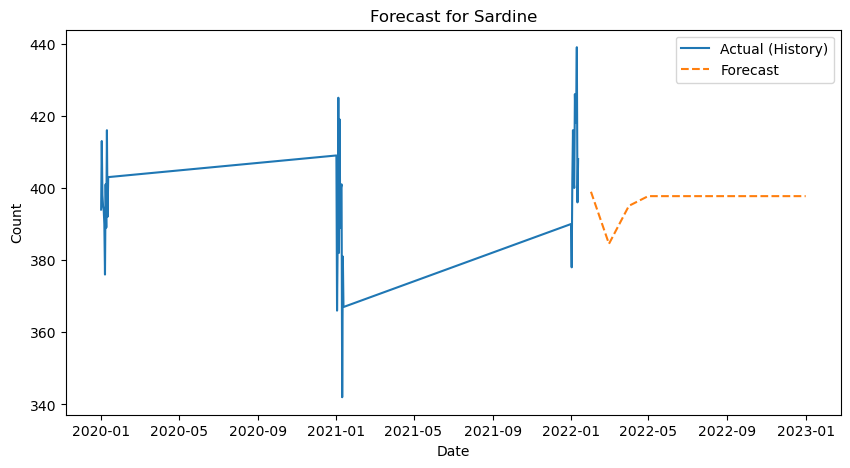

36    398.943267
37    384.508279
38    395.038948
39    397.728620
40    397.728620
41    397.728620
42    397.728620
43    397.728620
44    397.728620
45    397.728620
46    397.728620
47    397.728620
dtype: float64

🔹 Forecasting for Snapper ...


c:\Users\a30ku\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\a30ku\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


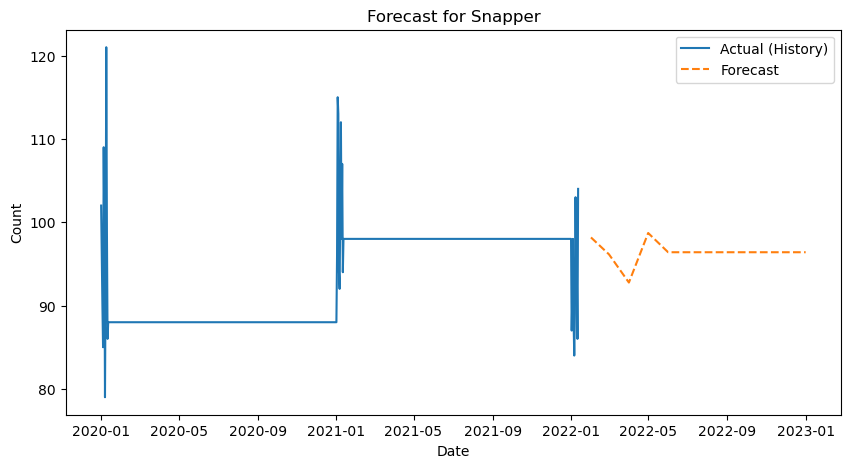

36    98.173807
37    96.146249
38    92.760031
39    98.705507
40    96.398410
41    96.398410
42    96.398410
43    96.398410
44    96.398410
45    96.398410
46    96.398410
47    96.398410
dtype: float64

🔹 Forecasting for Tuna ...


c:\Users\a30ku\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\a30ku\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


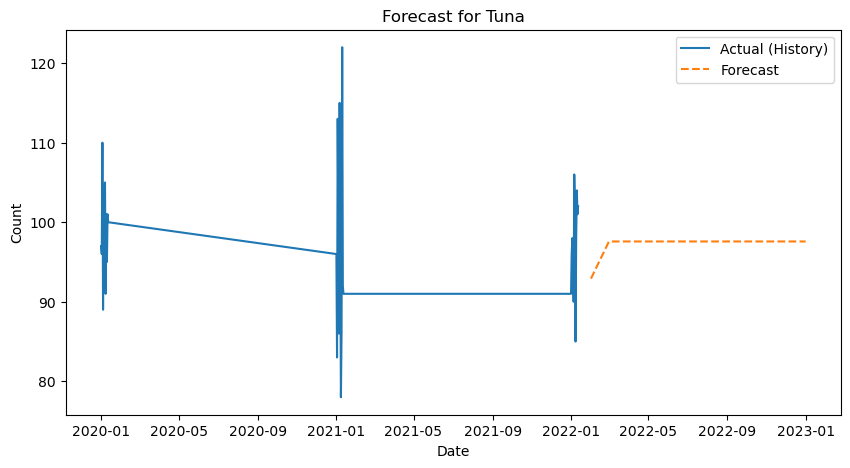

36    92.912059
37    97.580234
38    97.580234
39    97.580234
40    97.580234
41    97.580234
42    97.580234
43    97.580234
44    97.580234
45    97.580234
46    97.580234
47    97.580234
dtype: float64


In [7]:
for sp in species_list:
    print(f"\n🔹 Forecasting for {sp} ...")
    forecast_values = forecast_species(df_grouped, sp, steps=12)
    print(forecast_values)